# Retrieval Augmented Generation with LangGraph

## Initial Setup

In [1]:
# !uv pip install langgraph

In [2]:
import os, json, re, getpass, warnings
import numpy as np
from dotenv import load_dotenv
from uuid import uuid4
from IPython.display import display, Markdown

In [3]:
warnings.filterwarnings('ignore')
load_dotenv(override=True)

True

In [4]:
#Check for Groq API Key
if "GROQ_API_KEY" not in os.environ:
    os.environ["GROQ_API_KEY"] = getpass.getpass("GROQ API Key: ")

## Defining Components

In [5]:
# Question
question = "What is the PGP AI & DS at Jio Institute all about?"

### Chat Model

In [6]:
from langchain.chat_models import init_chat_model

model_name = "llama-3.1-8b-instant"
llm = init_chat_model(model_name, model_provider="groq") #Other Llama alternatives available are llama3-8b-8192, llama-3.3-70b-versatile

### Embedding Model

In [7]:
!ollama pull llama3.1:8b

pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest ⠴ pulling manifest ⠦ pulling manifest ⠧ pulling manifest ⠇ pulling manifest ⠏ pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest ⠴ pulling manifest ⠦ pulling manifest ⠧ pulling manifest 
pulling 667b0c1932bc: 100% ▕██████████████████▏ 4.9 GB                         
pulling 948af2743fc7: 100% ▕██████████████████▏ 1.5 KB                         
pulling 0ba8f0e314b4: 100% ▕██████████████████▏  12 KB                         
pulling 56bb8bd477a5: 100% ▕██████████████████▏   96 B                         
pulling 455f34728c9b: 100% ▕██████████████████▏  487 B                         
verifying sha256 digest 
writing manifest 
success 


In [8]:
from langchain_ollama import OllamaEmbeddings

embeddings_model = OllamaEmbeddings(model="llama3.1:8b")

### Vector Store

In [9]:
#Import libraries
import faiss
from langchain_community.docstore.in_memory import InMemoryDocstore
from langchain_community.vectorstores import FAISS

In [10]:
#To get the dimension of the embedding generated by the model
query_embedding = embeddings_model.embed_query("Hello world!")
len(query_embedding)

4096

In [11]:
#Initialize the index (using the basic IndexFlatL2 - there are IndexIVFFlat and IndexIVFPQ also available that're faster. Note the tradeoff between accuracy and speed)
index = faiss.IndexFlatL2(len(query_embedding))

In [12]:
#Create a vector store
vector_store_faiss = FAISS(
    embedding_function=embeddings_model,
    index=index,
    docstore=InMemoryDocstore(),
    index_to_docstore_id={},
)

## Indexing

### Loading Documents

In [13]:
import bs4 #import Beautiful Soup
from langchain_community.document_loaders import WebBaseLoader

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [14]:
# Only keep the main content from the full HTML
bs4_strainer = bs4.SoupStrainer(class_=("node__content clearfix", "col-md-9 pl-lg-5"))
loader = WebBaseLoader(
    web_paths=("https://www.jioinstitute.edu.in/about/",
    "https://www.jioinstitute.edu.in/academics/artificial-intelligence-data-science"),
    bs_kwargs={"parse_only": bs4_strainer},
)
docs = loader.load()

assert len(docs) == 2

In [15]:
# --- Post-processing to clean up excessive newlines and whitespace ---
for i, doc in enumerate(docs):
    if doc.page_content:
        # 1. Replace multiple newlines with a single newline
        cleaned_content = re.sub(r'\n\s*\n', '\n\n', doc.page_content)
        # 2. Replace multiple spaces with a single space
        cleaned_content = re.sub(r' {2,}', ' ', cleaned_content)
        # 3. Strip leading/trailing whitespace from each line
        cleaned_content = '\n'.join([line.strip() for line in cleaned_content.split('\n')])
        # 4. Remove leading/trailing whitespace from the whole string
        cleaned_content = cleaned_content.strip()
    
        docs[i].page_content = cleaned_content
# --- End of post-processing ---

### Splitting Documents

In [16]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,  # chunk size (characters)
    chunk_overlap=200,  # chunk overlap (characters)
    add_start_index=True,  # track index in original document
)
all_splits = text_splitter.split_documents(docs)

print(f"Split blog post into {len(all_splits)} sub-documents.")

Split blog post into 62 sub-documents.


### Storing in Vector Store

In [17]:
#Add first 5 chunks to vector DB
uuids = [str(uuid4()) for _ in range(len(all_splits))] #Universally unique identifier
vector_store_faiss.add_documents(documents=all_splits[:5], ids=uuids[:5])

['7e9034a8-16d5-4e7c-806b-2228612c9b92',
 '224f0e03-b6d5-4ce9-b5d8-57899acf9811',
 '2e48329d-9db2-48ab-96cc-3d830f0b2868',
 '207253e0-87cd-4b91-857d-8377fcbb39ee',
 '790ef996-e19e-4dbf-a024-85415756def1']

## Retrieval and Generation with LangGraph

### Define Prompt

In [18]:
#Use Prompt Template
from langchain import hub

prompt = hub.pull("rlm/rag-prompt")

example_messages = prompt.invoke(
    {"context": "(context goes here)", "question": "(question goes here)"}
).to_messages()

assert len(example_messages) == 1
print(example_messages[0].content)

You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.
Question: (question goes here) 
Context: (context goes here) 
Answer:


### Create Graph

In [19]:
from langchain_core.documents import Document
from typing_extensions import List, TypedDict

class State(TypedDict):
    question: str
    context: List[Document]
    answer: str

In [20]:
def retrieve(state: State):
    retrieved_docs = vector_store_faiss.similarity_search(state["question"])
    return {"context": retrieved_docs}

def generate(state: State):
    docs_content = "\n\n".join(doc.page_content for doc in state["context"])
    messages = prompt.invoke({"question": state["question"], "context": docs_content})
    response = llm.invoke(messages)
    return {"answer": response.content}

In [65]:
from langgraph.graph import START, StateGraph, END

graph_builder = StateGraph(State)

graph_builder.add_node("retrieve", retrieve)
graph_builder.add_node("generate", generate)

graph_builder.add_edge(START, "retrieve")
graph_builder.add_edge("retrieve","generate")
graph_builder.add_edge("generate",END)

graph = graph_builder.compile()

# # Add memory
# memory = MemorySaver()
# graph = graph_builder.compile(checkpointer=memory)

# config = {"configurable": {"thread_id": "abc123"}}

In [66]:
# from langgraph.graph import START, StateGraph

# graph_builder = StateGraph(State).add_sequence([retrieve, generate])
# graph_builder.add_edge(START, "retrieve")
# graph = graph_builder.compile()

# # # Add memory
# # memory = MemorySaver()
# # graph = graph_builder.compile(checkpointer=memory)

# # config = {"configurable": {"thread_id": "abc123"}}

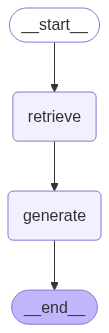

In [67]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

### Invoke Graph

In [68]:
result = graph.invoke({"question": question})

## ----- To run with memory -----
# result = graph.invoke({"question": question},config)

print(f'Context: {result["context"]}\n\n')
print(f'Answer: {result["answer"]}')

Context: [Document(id='cc695d83-0975-48e4-ae6b-addaf5f06802', metadata={'source': 'https://www.jioinstitute.edu.in/about/', 'start_index': 2588}, page_content='Former Executive Chairman, Brookings India | Former CEO, Shell India\n\nSee Profile\n\nMr. Jalaj Dani\n\nChairman of the Board of Governors, IIM Trichy | Co-Promoter, Asian Paints\n\nSee Profile\n\nMr. R. Venkataramanan\n\nFormer Managing Trustee, Tata Trusts\n\nSee Profile\n\nJio Institute Leadership\nFrom reputed academicians and researchers around the world to Indian stalwarts across the spectrum – Jio Institute’s distinguished leadership is committed to guiding the Institute from strength to strength.\n\nChancellor\nDr. Raghunath Mashelkar\n\nPadma Vibhushan | Former Director General, CSIR, Government of India\n\nSee Profile\n\nVICE-CHANCELLOR\nDr. Dipak Jain\n\nFormer Dean, Kellogg School of Management, USA | Former Dean, INSEAD, France\n\nSee Profile\n\nCampus Experience & Student Life\nA vibrant campus replete with world-